# 1. Import the libraries:

In [16]:
%pwd

'D:\\ML and AI Engineer\\Projects\\An-end-to-end-customer-churn-prediction-model'

In [3]:
import os

os.chdir("..")

In [176]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder, RobustScaler, OrdinalEncoder
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.feature_selection import mutual_info_classif
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_selection import SelectKBest, chi2, RFE
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score, RepeatedStratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
%matplotlib inline

In [18]:
# os.chdir("../")
%pwd

'D:\\ML and AI Engineer\\Projects\\An-end-to-end-customer-churn-prediction-model'

### Load the data:

In [64]:
clipped_train = pd.read_parquet("Artifacts/feature_engineering/data_clipped/train.parquet")
clipped_test = pd.read_parquet("Artifacts/feature_engineering/data_clipped/test.parquet")

unclipped_train = pd.read_parquet("Artifacts/feature_engineering/data_unclipped/train.parquet")
unclipped_test = pd.read_parquet("Artifacts/feature_engineering/data_unclipped/test.parquet")

In [65]:
clipped_train.columns

Index(['customerid', 'order_frequency', 'total_monetary_value',
       'total_quantity_abs', 'total_order_issues', 'country',
       'avg_order_value', 'avg_quantity_per_order',
       'customer_order_issue_rate', 'recency', 'tenure',
       'avg_stockcode_issue_rate', 'max_stockcode_issue_rate',
       'total_orders_made_for_stock', 'churn'],
      dtype='object')

In [66]:
unclipped_train.columns

Index(['customerid', 'order_frequency', 'total_monetary_value',
       'total_quantity_abs', 'total_order_issues', 'country',
       'avg_order_value', 'avg_quantity_per_order',
       'customer_order_issue_rate', 'recency', 'tenure',
       'avg_stockcode_issue_rate', 'max_stockcode_issue_rate',
       'total_orders_made_for_stock', 'churn'],
      dtype='object')

# 2. Using the `Clipped data` for the experimentation:

In [67]:
clipped_train.isna().sum()

customerid                     0
order_frequency                0
total_monetary_value           0
total_quantity_abs             0
total_order_issues             0
country                        0
avg_order_value                0
avg_quantity_per_order         0
customer_order_issue_rate      0
recency                        0
tenure                         0
avg_stockcode_issue_rate       0
max_stockcode_issue_rate       0
total_orders_made_for_stock    0
churn                          0
dtype: int64

## 2.1 Define the dependent and independent features:

In [183]:
def create_dep_indep_features(df:pd.DataFrame):
    """
    Splits the data into dependent(y) and independent(X) features:
    """
    df.dropna(inplace=True)
    X = df.drop(columns=['customerid', 'churn'])
    y = df['churn']
    return X, y
    
    

In [184]:
X_train, y_train = create_dep_indep_features(df=clipped_train)
X_test, y_test = create_dep_indep_features(df=clipped_test)

In [185]:
X_test.isna().sum()

order_frequency                0
total_monetary_value           0
total_quantity_abs             0
total_order_issues             0
country                        0
avg_order_value                0
avg_quantity_per_order         0
customer_order_issue_rate      0
recency                        0
tenure                         0
avg_stockcode_issue_rate       0
max_stockcode_issue_rate       0
total_orders_made_for_stock    0
dtype: int64

## 2.2 Define the column groups:

In [186]:
# For numerical features:
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# For categorical features:
categorical_features = X_train.select_dtypes(include=['object', 'string']).columns.tolist()

In [187]:
numerical_features

['order_frequency',
 'total_monetary_value',
 'total_quantity_abs',
 'total_order_issues',
 'avg_order_value',
 'avg_quantity_per_order',
 'customer_order_issue_rate',
 'recency',
 'tenure',
 'avg_stockcode_issue_rate',
 'max_stockcode_issue_rate',
 'total_orders_made_for_stock']

In [188]:
categorical_features

['country']

## 2.3 Scaling the features:

For scaling numerical features, we have these options:
1. Min-max scaler
2. Standardization
3. RobustScaler

But, to use standardization, it is important to have features that follow a normal-dirstribution for a better results, below,
none of the features follow a normal/gaussian distribution, so, i will be testing out both the sacling techniques, and later finalize the method based on the model's performance on the testing set.

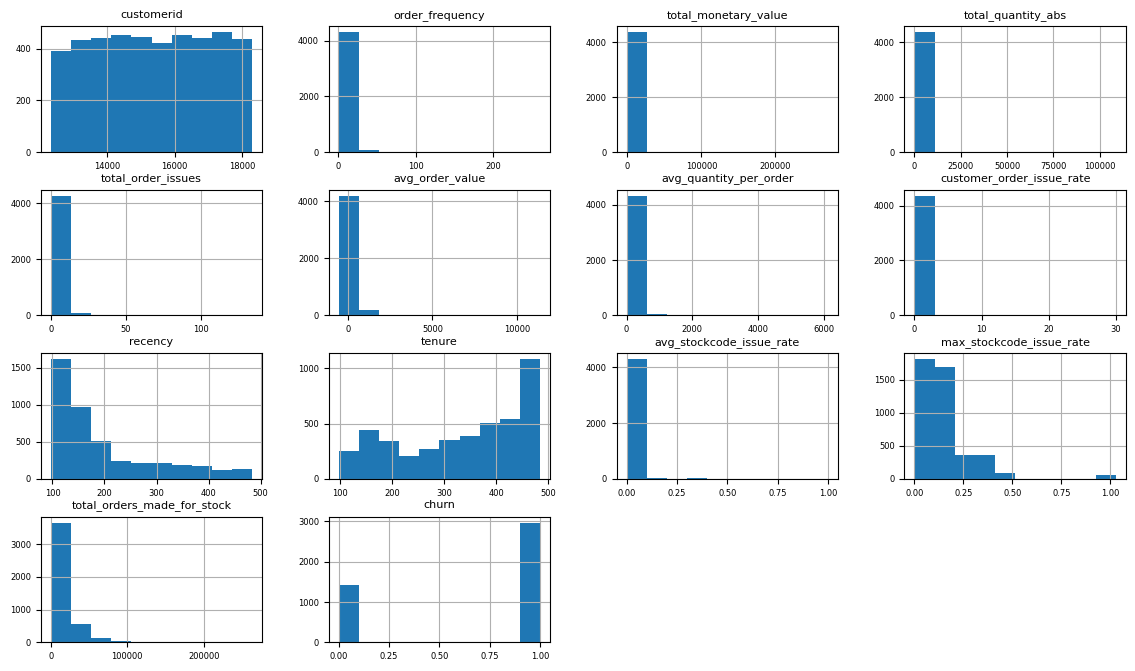

In [189]:
fig = clipped_train.hist(xlabelsize=6, ylabelsize=6, figsize=(14, 8))
[x.title.set_size(8) for x in fig.ravel()]
plt.show()

In [190]:
X_test.shape

(4141, 13)

In [191]:
y_test.shape

(4141,)

## 2.4 Correlation and Multi-collinearity check:

#### 2.4.1 Correlation:

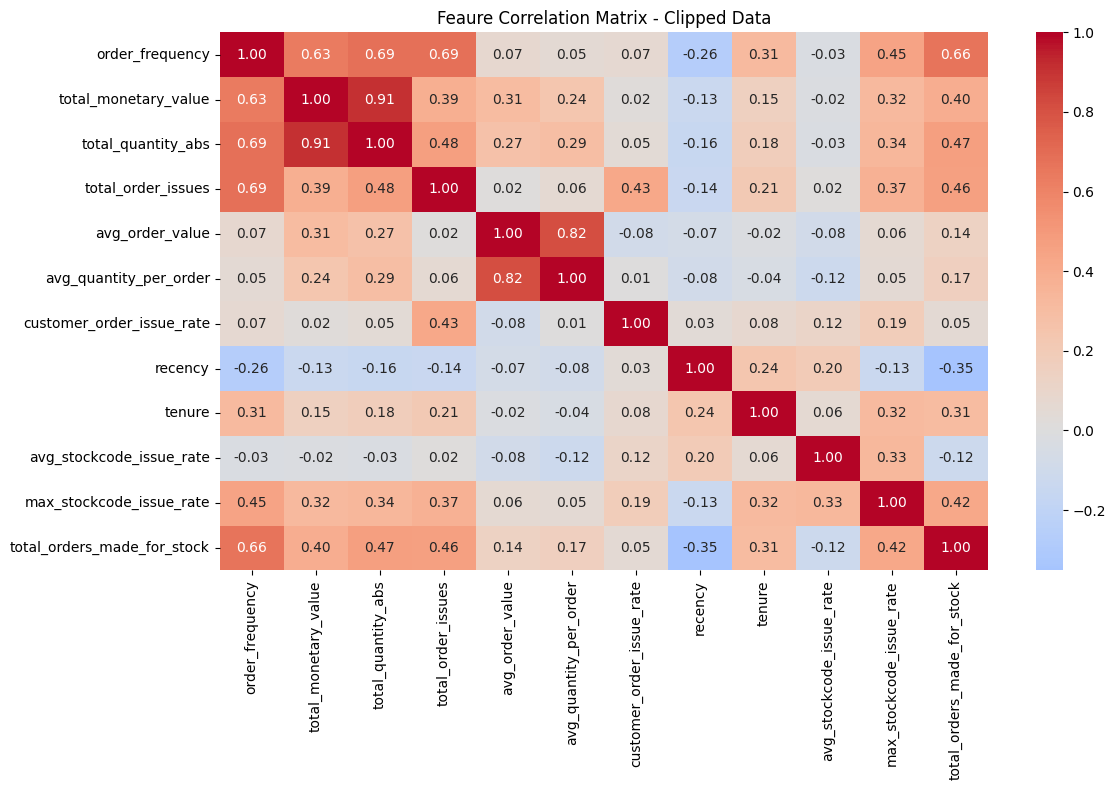

In [192]:
corr = X_train[numerical_features].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title("Feaure Correlation Matrix - Clipped Data")
plt.tight_layout()
plt.show()

#### 2.4.2 Multi-collinearity:

In [193]:
def compute_vif(df:pd.DataFrame, features:list) -> pd.DataFrame:
    X_num = df[features].copy()
    vif_data= pd.DataFrame({
        'feature': features,
        'VIF': [variance_inflation_factor(X_num.values, i) for i in range(X_num.shape[1])]
    })
    return vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

In [194]:
def drop_high_vif(X: pd.DataFrame, features: list,
                  threshold: float = 10.0) -> list:
    features = features.copy()
    print(f"Starting VIF filter | threshold: {threshold}\n")
    while True:
        vif_df = compute_vif(X, features)
        max_vif   = vif_df.iloc[0]['VIF']
        max_feat  = vif_df.iloc[0]['feature']
        if max_vif <= threshold:
            print(f"All VIFs at or below {threshold}. Done.\n")
            break
        print(f"Dropping '{max_feat}' — VIF: {max_vif:.2f}")
        features.remove(max_feat)
    print(vif_df.to_string(index=False))
    return features

In [195]:
print("=== VIF Before Dropping ===")
print(compute_vif(X_train, numerical_features).to_string(index=False))

print("\n=== Iterative VIF Filtering ===")
numerical_features_vif_clean = drop_high_vif(X_train, numerical_features,
                                              threshold=10.0)
print("\n=== Cleaned Numerical Features ===")
numerical_features_vif_clean

=== VIF Before Dropping ===
                    feature      VIF
                     tenure 9.432592
         total_quantity_abs 8.392291
       total_monetary_value 7.346603
     avg_quantity_per_order 6.341679
                    recency 5.820649
            avg_order_value 5.643128
            order_frequency 5.550459
   max_stockcode_issue_rate 3.799277
total_orders_made_for_stock 3.706678
         total_order_issues 2.972992
   avg_stockcode_issue_rate 1.804312
  customer_order_issue_rate 1.597849

=== Iterative VIF Filtering ===
Starting VIF filter | threshold: 10.0

All VIFs at or below 10.0. Done.

                    feature      VIF
                     tenure 9.432592
         total_quantity_abs 8.392291
       total_monetary_value 7.346603
     avg_quantity_per_order 6.341679
                    recency 5.820649
            avg_order_value 5.643128
            order_frequency 5.550459
   max_stockcode_issue_rate 3.799277
total_orders_made_for_stock 3.706678
         total_

['order_frequency',
 'total_monetary_value',
 'total_quantity_abs',
 'total_order_issues',
 'avg_order_value',
 'avg_quantity_per_order',
 'customer_order_issue_rate',
 'recency',
 'tenure',
 'avg_stockcode_issue_rate',
 'max_stockcode_issue_rate',
 'total_orders_made_for_stock']

#### Mutual Information:

In [201]:
def compute_mutual_info(X: pd.DataFrame, y: pd.Series,
                        numerical_features: list,
                        categorical_features: list) -> pd.DataFrame:
    
    all_features = numerical_features + categorical_features
    X_mi = X[all_features].copy()
    
    # Encode country as integer for MI calculation
    X_mi['country'] = X_mi['country'].astype('category').cat.codes
    
    # discrete_features: True for categorical, False for continuous
    discrete_mask = [False] * len(numerical_features) + [True] * len(categorical_features)
    
    mi_scores = mutual_info_classif(
        X_mi, y,
        discrete_features=discrete_mask,
        random_state=42
    )
    
    mi_df = pd.DataFrame({
        'feature':  all_features,
        'MI_score': mi_scores
    }).sort_values('MI_score', ascending=False).reset_index(drop=True)
    
    return mi_df


def plot_mutual_info(mi_df: pd.DataFrame, branch_name:str):
    plt.figure(figsize=(10, 6))
    colors = ['#2ecc71' if s > 0.01 else '#e74c3c'
              for s in mi_df['MI_score']]
    plt.barh(mi_df['feature'], mi_df['MI_score'], color=colors)
    plt.xlabel('Mutual Information Score')
    plt.title(f'Feature Relevance to Churn (Mutual Information): {branch_name}')
    plt.axvline(x=0.01, color='black', linestyle='--',
                linewidth=1, label='Threshold (0.01)')
    plt.legend()
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


=== Mutual Information Scores ===
                    feature  MI_score
            order_frequency  0.125664
       total_monetary_value  0.115125
         total_quantity_abs  0.104112
                    recency  0.080149
total_orders_made_for_stock  0.075252
  customer_order_issue_rate  0.071840
     avg_quantity_per_order  0.046071
         total_order_issues  0.043682
   max_stockcode_issue_rate  0.027463
                     tenure  0.017615
   avg_stockcode_issue_rate  0.016052
            avg_order_value  0.008408
                    country  0.007609


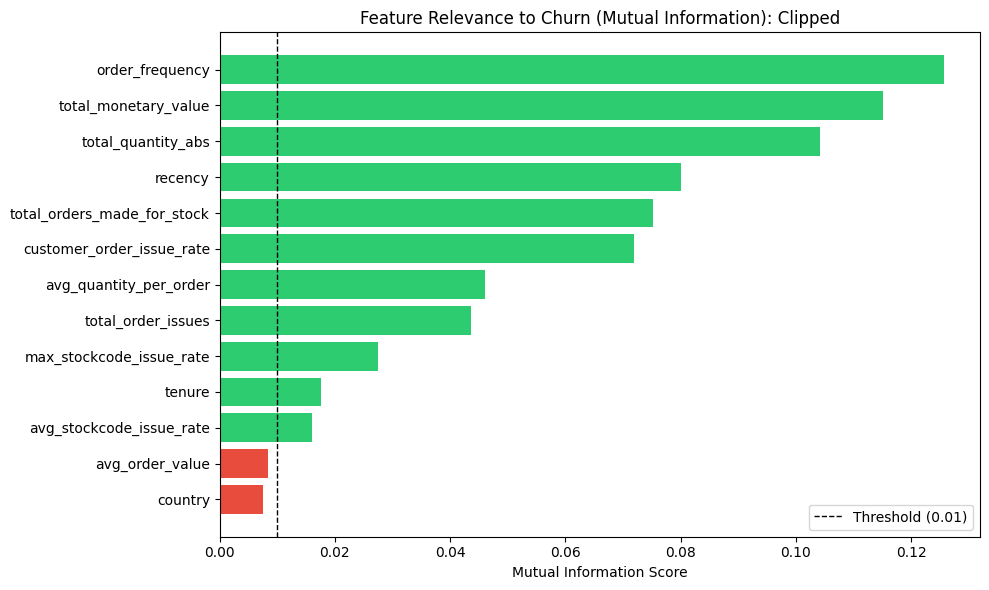


Features kept after MI filter (11): ['order_frequency', 'total_monetary_value', 'total_quantity_abs', 'recency', 'total_orders_made_for_stock', 'customer_order_issue_rate', 'avg_quantity_per_order', 'total_order_issues', 'max_stockcode_issue_rate', 'tenure', 'avg_stockcode_issue_rate']
Features dropped (2):  ['avg_order_value', 'country']


In [202]:
mi_df = compute_mutual_info(
    X_train, y_train,
    numerical_features=numerical_features_vif_clean,
    categorical_features=categorical_features
)

print("=== Mutual Information Scores ===")
print(mi_df.to_string(index=False))
plot_mutual_info(mi_df, branch_name='Clipped')

# Features to keep: MI score above 0.01
features_to_keep = mi_df[mi_df['MI_score'] > 0.01]['feature'].tolist()
print(f"\nFeatures kept after MI filter ({len(features_to_keep)}): {features_to_keep}")

# Features dropped: MI score at or below 0.01
features_dropped = mi_df[mi_df['MI_score'] <= 0.01]['feature'].tolist()
print(f"Features dropped ({len(features_dropped)}):  {features_dropped}")

In [203]:
features_to_keep

['order_frequency',
 'total_monetary_value',
 'total_quantity_abs',
 'recency',
 'total_orders_made_for_stock',
 'customer_order_issue_rate',
 'avg_quantity_per_order',
 'total_order_issues',
 'max_stockcode_issue_rate',
 'tenure',
 'avg_stockcode_issue_rate']

## 2.5 Testing scalers and encodings:

### 1. Testing with `StandardScaler()` with `KNN()`:

with `SMOTE()`:

In [204]:
std_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), features_to_keep),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

pipeline = ImbPipeline([
    ('data_preparation', std_preprocessor), 
    ('smote', SMOTE(random_state=42)),
    ('clf', KNeighborsClassifier())
])


cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
n_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)

print(f"With 'StandardScaler() and OneHotEncoder()', on training data the mean f1-score is: {np.mean(n_scores)*100:.2f}% and the STD is: {np.std(n_scores)*100:.2f}%.")


pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print(f"With StandardScaler(), on test data, the accuracy: {accuracy_score(y_test, y_pred)*100:.2f}% |"
     f" precision: {precision_score(y_test, y_pred)*100:.2f} | recall: {recall_score(y_test, y_pred)*100:.2f}% |",
     f"and F1-score: {f1_score(y_test, y_pred)*100:.2f}% ")

With 'StandardScaler() and OneHotEncoder()', on training data the mean f1-score is: 74.12% and the STD is: 1.71%.
With StandardScaler(), on test data, the accuracy: 69.02% | precision: 78.43 | recall: 76.04% | and F1-score: 77.22% 


In [205]:
std_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), features_to_keep),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

pipeline = Pipeline([
    ('data_preparation', std_preprocessor), 
    ('clf', KNeighborsClassifier())
])


cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
n_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)

print(f"With 'StandardScaler() and OneHotEncoder()', on training data the mean f1-score is: {np.mean(n_scores)*100:.2f}% and the STD is: {np.std(n_scores)*100:.2f}%.")


pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print(f"With StandardScaler(), on test data, the accuracy: {accuracy_score(y_test, y_pred)*100:.2f}% |"
     f" precision: {precision_score(y_test, y_pred)*100:.2f} | recall: {recall_score(y_test, y_pred)*100:.2f}% |",
     f"and F1-score: {f1_score(y_test, y_pred)*100:.2f}% ")

With 'StandardScaler() and OneHotEncoder()', on training data the mean f1-score is: 81.66% and the STD is: 1.09%.
With StandardScaler(), on test data, the accuracy: 74.74% | precision: 76.59 | recall: 91.33% | and F1-score: 83.31% 


### 2. Testing with `MinMaxScaler()` with `KNN()`:

In [206]:
min_max_procesor = ColumnTransformer([
    ('num', MinMaxScaler(), features_to_keep),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

pipeline = Pipeline([
    ('data_preparation', min_max_procesor),
    ('clf', KNeighborsClassifier())
])


cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
n_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
print(f"With 'MinMaxScaler() and OneHotEncoder()', the mean score is: {np.mean(n_scores)*100:.2f}% and the STD is: {np.std(n_scores)*100:.2f}%.")

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print(f"With StandardScaler(), the accuracy: {accuracy_score(y_test, y_pred)*100:.2f}% |"
     f" precision: {precision_score(y_test, y_pred)*100:.2f} | recall: {recall_score(y_test, y_pred)*100:.2f}% |",
     f"and F1-score: {f1_score(y_test, y_pred)*100:.2f}% ")

With 'MinMaxScaler() and OneHotEncoder()', the mean score is: 72.54% and the STD is: 1.46%.
With StandardScaler(), the accuracy: 73.90% | precision: 76.38 | recall: 90.03% | and F1-score: 82.65% 


### 3. Testing with `RobustScaler()`with `KNN()`:

In [207]:
robust_preprocess = ColumnTransformer([
    ('num', RobustScaler(), features_to_keep),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

pipeline = Pipeline([
    ('data_preparation', robust_preprocess),
    ('clf', KNeighborsClassifier())
])


cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
n_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
print(f"With 'RobustScaler() and OneHotEncoder()', the mean score is: {np.mean(n_scores)*100:.2f}% and the STD is: {np.std(n_scores)*100:.2f}%.")

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print(f"With StandardScaler(), the accuracy: {accuracy_score(y_test, y_pred)*100:.2f}% |"
     f" precision: {precision_score(y_test, y_pred)*100:.2f} | recall: {recall_score(y_test, y_pred)*100:.2f}% |",
     f"and F1-score: {f1_score(y_test, y_pred)*100:.2f}% ")

With 'RobustScaler() and OneHotEncoder()', the mean score is: 74.73% and the STD is: 1.65%.
With StandardScaler(), the accuracy: 73.82% | precision: 75.78 | recall: 91.26% | and F1-score: 82.80% 


`RobustScaler() and OneHotEncoder()` seems to be the best option for scaling and encoding.

## 2.6 Spot-checking algorithms (Clipped-Data):

### Defining the pre-procesor:

In [208]:
preprocessor = ColumnTransformer([
    ('num', RobustScaler(), features_to_keep),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

### Spot-checking the algorithms:

In [209]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
results = []
names = []

models = {
    'LR': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'DT': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'RF': RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42),
    'EXTCLF': ExtraTreesClassifier(class_weight='balanced', n_estimators=100, random_state=42),
    'GB': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XG': XGBClassifier(scale_pos_weight=2, eval_metric='logloss', random_state=42, verbosity=0),
    'KNN': KNeighborsClassifier(),
    'LDA': LinearDiscriminantAnalysis(),
    'SVC': SVC()
}

In [210]:
for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('clf', model)
    ])
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
    results.append(scores)
    names.append(name)
    print(f"{name:25s} | F1: {np.mean(scores)*100:.2f}% ± {np.std(scores)*100:.2f}%")

LR                        | F1: 80.06% ± 0.91%
DT                        | F1: 76.33% ± 1.42%
RF                        | F1: 84.03% ± 0.63%
EXTCLF                    | F1: 83.82% ± 0.59%
GB                        | F1: 84.12% ± 0.53%
XG                        | F1: 83.29% ± 0.60%
KNN                       | F1: 82.20% ± 0.87%
LDA                       | F1: 82.94% ± 0.89%
SVC                       | F1: 84.39% ± 0.50%


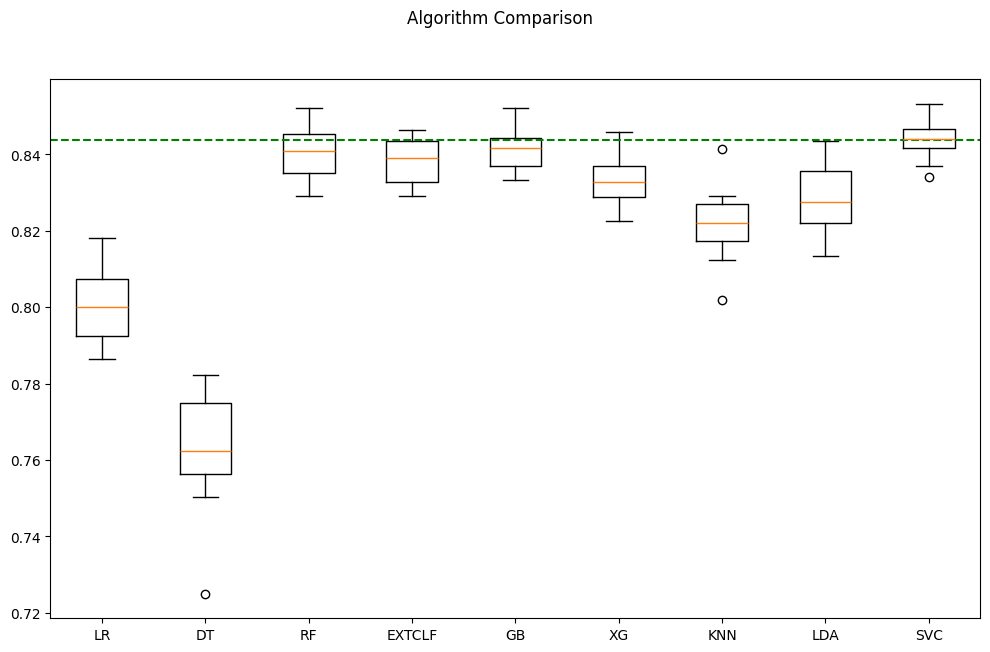

In [211]:
fig = plt.figure(figsize=(12, 7))
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
plt.axhline(y=scores.mean(), color ="green", linestyle ="--")
ax.set_xticklabels(names)
plt.show()

For clipped data, I will be moving forward with, tune the hyper-parameter, test with/without `RFECV` and evaluate on the test data:
1. `RandomForestClassifier()`
2. `ExtraTreesClassifier()`
3. `GradientBoostingClassifier()` and
4. `SVC()`

# 3. Spot-checking algorithms (Unclipped-Data):

## 3.1 Define the dependent and independent features:

In [212]:
X_train, y_train = create_dep_indep_features(df=unclipped_train)
X_test, y_test = create_dep_indep_features(df=unclipped_test)

In [213]:
X_test.isna().sum()

order_frequency                0
total_monetary_value           0
total_quantity_abs             0
total_order_issues             0
country                        0
avg_order_value                0
avg_quantity_per_order         0
customer_order_issue_rate      0
recency                        0
tenure                         0
avg_stockcode_issue_rate       0
max_stockcode_issue_rate       0
total_orders_made_for_stock    0
dtype: int64

## 3.2 Define the column groups:

In [214]:
# For numerical features:
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# For categorical features:
categorical_features = X_train.select_dtypes(include=['object', 'string']).columns.tolist()

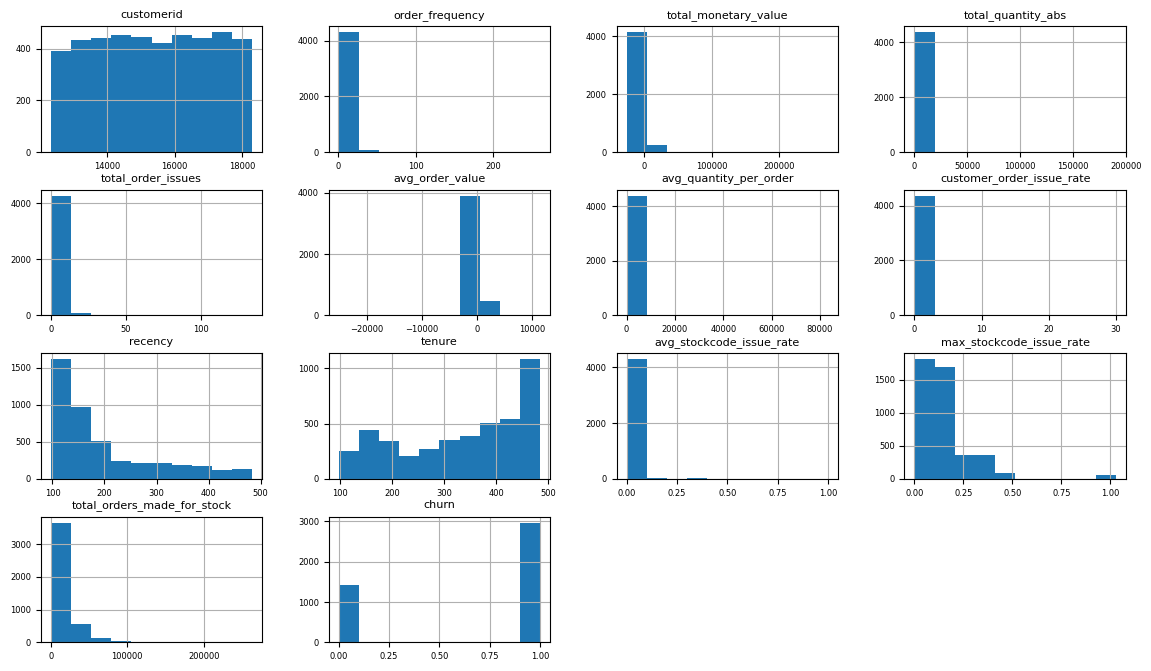

In [215]:
fig = unclipped_train.hist(xlabelsize=6, ylabelsize=6, figsize=(14, 8))
[x.title.set_size(8) for x in fig.ravel()]
plt.show()

## 3.3 Correlation and Multi-collinearity check:

### 3.3.1 Correlation:

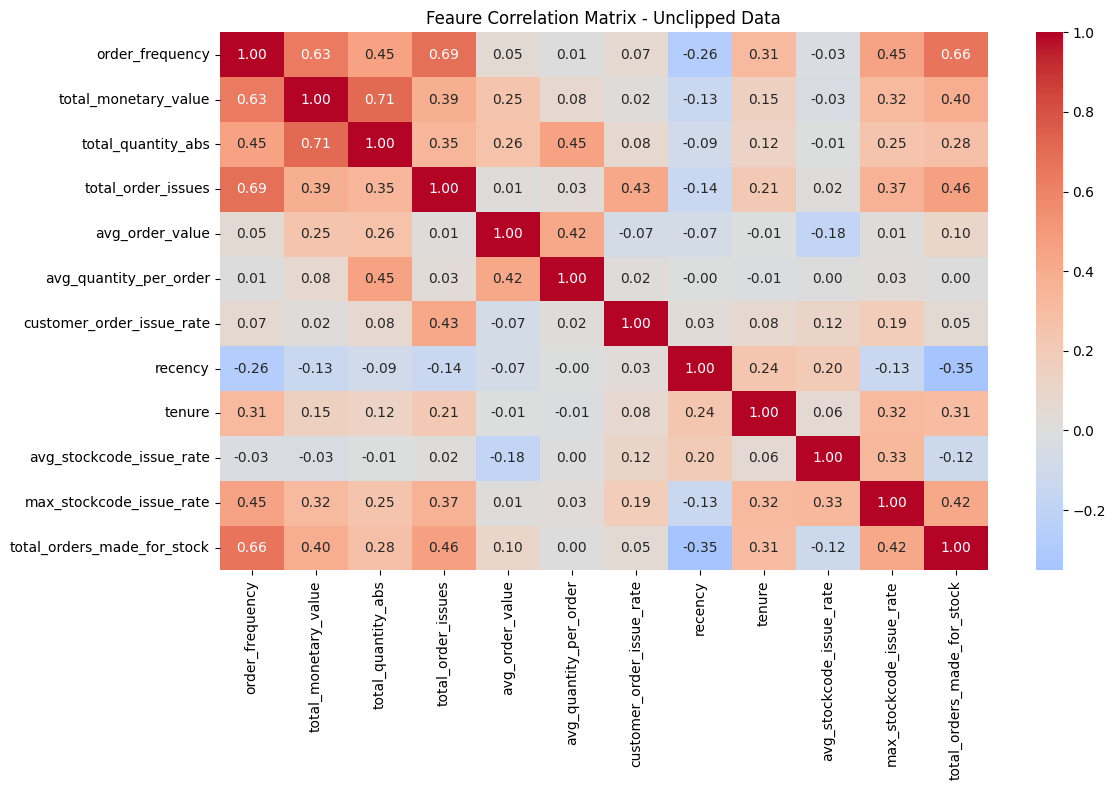

In [216]:
corr = X_train[numerical_features].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title("Feaure Correlation Matrix - Unclipped Data")
plt.tight_layout()
plt.show()

### 3.3.2 Multi-collinearity::

In [217]:
print("=== VIF Before Dropping ===")
print(compute_vif(X_train, numerical_features).to_string(index=False))

print("\n=== Iterative VIF Filtering ===")
numerical_features_vif_clean = drop_high_vif(X_train, numerical_features,
                                              threshold=10.0)
print("\n=== Cleaned Numerical Features ===")
numerical_features_vif_clean

=== VIF Before Dropping ===
                    feature      VIF
                     tenure 9.382141
                    recency 5.733288
            order_frequency 5.380887
   max_stockcode_issue_rate 3.792036
       total_monetary_value 3.624568
total_orders_made_for_stock 3.554972
         total_quantity_abs 3.281524
         total_order_issues 2.956313
     avg_quantity_per_order 1.867403
   avg_stockcode_issue_rate 1.843956
            avg_order_value 1.661510
  customer_order_issue_rate 1.570638

=== Iterative VIF Filtering ===
Starting VIF filter | threshold: 10.0

All VIFs at or below 10.0. Done.

                    feature      VIF
                     tenure 9.382141
                    recency 5.733288
            order_frequency 5.380887
   max_stockcode_issue_rate 3.792036
       total_monetary_value 3.624568
total_orders_made_for_stock 3.554972
         total_quantity_abs 3.281524
         total_order_issues 2.956313
     avg_quantity_per_order 1.867403
   avg_stockcod

['order_frequency',
 'total_monetary_value',
 'total_quantity_abs',
 'total_order_issues',
 'avg_order_value',
 'avg_quantity_per_order',
 'customer_order_issue_rate',
 'recency',
 'tenure',
 'avg_stockcode_issue_rate',
 'max_stockcode_issue_rate',
 'total_orders_made_for_stock']

### 3.3.3 Mutual Information:

=== Mutual Information Scores ===
                    feature  MI_score
            order_frequency  0.125664
       total_monetary_value  0.117527
         total_quantity_abs  0.099246
                    recency  0.080149
total_orders_made_for_stock  0.075252
  customer_order_issue_rate  0.071840
     avg_quantity_per_order  0.058417
         total_order_issues  0.043682
   max_stockcode_issue_rate  0.027463
                     tenure  0.017615
            avg_order_value  0.016286
   avg_stockcode_issue_rate  0.016052
                    country  0.007609


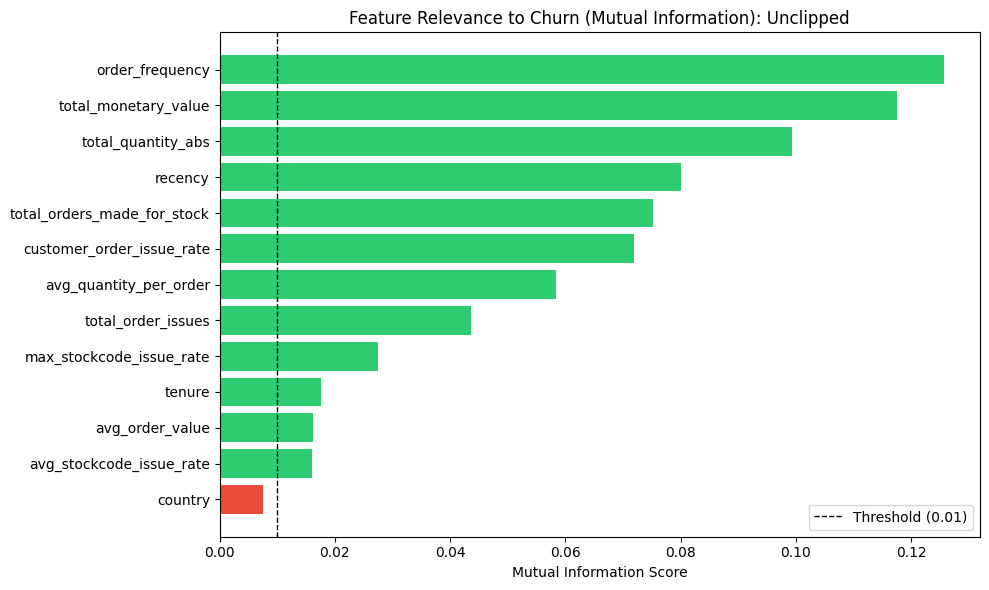


Features kept after MI filter (12): ['order_frequency', 'total_monetary_value', 'total_quantity_abs', 'recency', 'total_orders_made_for_stock', 'customer_order_issue_rate', 'avg_quantity_per_order', 'total_order_issues', 'max_stockcode_issue_rate', 'tenure', 'avg_order_value', 'avg_stockcode_issue_rate']
Features dropped (1):  ['country']


In [218]:
mi_df = compute_mutual_info(
    X_train, y_train,
    numerical_features=numerical_features_vif_clean,
    categorical_features=categorical_features
)

print("=== Mutual Information Scores ===")
print(mi_df.to_string(index=False))
plot_mutual_info(mi_df, branch_name='Unclipped')

# Features to keep: MI score above 0.01
features_to_keep = mi_df[mi_df['MI_score'] > 0.01]['feature'].tolist()
print(f"\nFeatures kept after MI filter ({len(features_to_keep)}): {features_to_keep}")

# Features dropped: MI score at or below 0.01
features_dropped = mi_df[mi_df['MI_score'] <= 0.01]['feature'].tolist()
print(f"Features dropped ({len(features_dropped)}):  {features_dropped}")

In [220]:
features_to_keep

['order_frequency',
 'total_monetary_value',
 'total_quantity_abs',
 'recency',
 'total_orders_made_for_stock',
 'customer_order_issue_rate',
 'avg_quantity_per_order',
 'total_order_issues',
 'max_stockcode_issue_rate',
 'tenure',
 'avg_order_value',
 'avg_stockcode_issue_rate']

## 3.4 Testing scalers and encodings:

### 3.4.1 `StandardScaler()`:

In [221]:
std_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), features_to_keep),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

pipeline = Pipeline([
    ('data_preparation', std_preprocessor), 
    ('clf', KNeighborsClassifier())
])


cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
n_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)

print(f"With 'StandardScaler() and OneHotEncoder()', on training data the mean f1-score is: {np.mean(n_scores)*100:.2f}% and the STD is: {np.std(n_scores)*100:.2f}%.")


pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print(f"With StandardScaler(), on test data, the accuracy: {accuracy_score(y_test, y_pred)*100:.2f}% |"
     f" precision: {precision_score(y_test, y_pred)*100:.2f} | recall: {recall_score(y_test, y_pred)*100:.2f}% |",
     f"and F1-score: {f1_score(y_test, y_pred)*100:.2f}% ")

With 'StandardScaler() and OneHotEncoder()', on training data the mean f1-score is: 81.75% and the STD is: 1.08%.
With StandardScaler(), on test data, the accuracy: 76.00% | precision: 77.32 | recall: 92.31% | and F1-score: 84.15% 


### 3.4.2 `MinMaxScaler()`:

In [222]:
min_max_procesor = ColumnTransformer([
    ('num', MinMaxScaler(), features_to_keep),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

pipeline = Pipeline([
    ('data_preparation', min_max_procesor),
    ('clf', KNeighborsClassifier())
])


cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
n_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
print(f"With 'MinMaxScaler() and OneHotEncoder()', the mean score is: {np.mean(n_scores)*100:.2f}% and the STD is: {np.std(n_scores)*100:.2f}%.")

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print(f"With StandardScaler(), the accuracy: {accuracy_score(y_test, y_pred)*100:.2f}% |"
     f" precision: {precision_score(y_test, y_pred)*100:.2f} | recall: {recall_score(y_test, y_pred)*100:.2f}% |",
     f"and F1-score: {f1_score(y_test, y_pred)*100:.2f}% ")

With 'MinMaxScaler() and OneHotEncoder()', the mean score is: 72.85% and the STD is: 1.55%.
With StandardScaler(), the accuracy: 73.92% | precision: 76.59 | recall: 89.61% | and F1-score: 82.59% 


### 3.4.3 `RobustScaler()`:

In [223]:
robust_preprocess = ColumnTransformer([
    ('num', RobustScaler(), features_to_keep),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

pipeline = Pipeline([
    ('data_preparation', robust_preprocess),
    ('clf', KNeighborsClassifier())
])


cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
n_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
print(f"With 'RobustScaler() and OneHotEncoder()', the mean score is: {np.mean(n_scores)*100:.2f}% and the STD is: {np.std(n_scores)*100:.2f}%.")

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print(f"With StandardScaler(), the accuracy: {accuracy_score(y_test, y_pred)*100:.2f}% |"
     f" precision: {precision_score(y_test, y_pred)*100:.2f} | recall: {recall_score(y_test, y_pred)*100:.2f}% |",
     f"and F1-score: {f1_score(y_test, y_pred)*100:.2f}% ")

With 'RobustScaler() and OneHotEncoder()', the mean score is: 74.69% and the STD is: 1.75%.
With StandardScaler(), the accuracy: 74.35% | precision: 76.01 | recall: 91.85% | and F1-score: 83.18% 


For unclipped data, `StandardScaler()` seems to be a better scaling method:

## 3.5 Spot-checking algorithms (Unclipped-Data):

### Define the pre-processor:

In [224]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), features_to_keep),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

### Spot-checking the algorithms:

In [225]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
results = []
names = []

models = {
    'LR': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'DT': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'RF': RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42),
    'EXTCLF': ExtraTreesClassifier(class_weight='balanced', n_estimators=100, random_state=42),
    'GB': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XG': XGBClassifier(scale_pos_weight=2, eval_metric='logloss', random_state=42, verbosity=0),
    'KNN': KNeighborsClassifier(),
    'LDA': LinearDiscriminantAnalysis(),
    'SVC': SVC()
}

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('clf', model)
    ])
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
    results.append(scores)
    names.append(name)
    print(f"{name:25s} | F1: {np.mean(scores)*100:.2f}% ± {np.std(scores)*100:.2f}%")

LR                        | F1: 80.12% ± 0.85%
DT                        | F1: 76.66% ± 1.17%
RF                        | F1: 84.22% ± 0.72%
EXTCLF                    | F1: 83.99% ± 0.79%
GB                        | F1: 84.11% ± 0.64%
XG                        | F1: 83.09% ± 0.85%
KNN                       | F1: 81.72% ± 0.95%
LDA                       | F1: 82.99% ± 0.81%
SVC                       | F1: 84.49% ± 0.59%


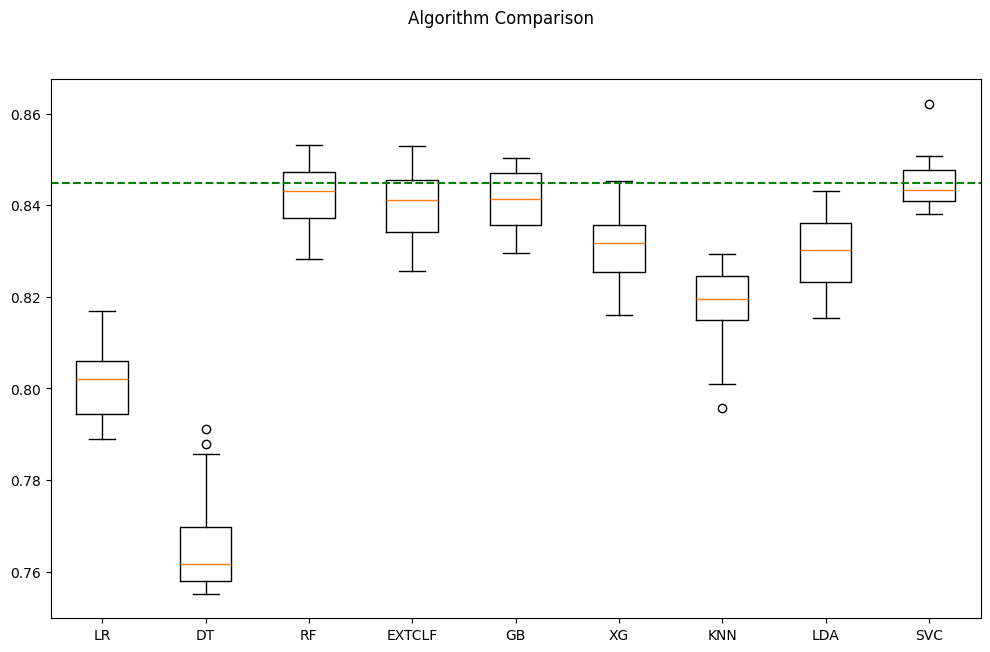

In [226]:
fig = plt.figure(figsize=(12, 7))
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
plt.axhline(y=scores.mean(), color ="green", linestyle ="--")
ax.set_xticklabels(names)
plt.show()